# Chapter 08b — Pulse Signalling and Matched-History Codewords

A one-bit "pulse" from a sender crystal can causally perturb a receiver's growth. Does it reliably do
so? Does the receiver register *when* a pulse arrived, distinguishably from noise? And does the specific
*arrangement* of several pulses (a short "codeword") leave a population-level signature an observer could
read back — or does that go a claim too far?

## Book linkage

- **Current chapter:** [`08-the-crystal-gets-a-past.md`](../content/books/digital-life/08-the-crystal-gets-a-past.md)
  (current book Chapter 8, "The Crystal Gets a Past")
- **Claims supported:** DL-08-C04, DL-08-C05, DL-08-C06, DL-08-C08 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:**
  - original book Chapter 16 ("Before There Are Messages"), legacy notebook
    `notebooks_original/16-before-there-are-messages.ipynb`; canonical
    `research/digital-life/ch16-reports/` (stages 00–07), verdict `CAUSAL_TRANSMISSION_SUPPORTED` (bounded).
  - the **terminal v6** of a separate chain, `research/digital-life/ch17-perturbation-dynamics-v6/`
    (`ch17-perturbation-dynamics-v6-full-report.md`) — this is what the *current* book's Chapter 8 quotes
    for the matched-history codeword test (codewords A=`11100001`, B=`10001101`, primary p=0.7366). This
    is **not** the same thread as `research/digital-life/ch17-reports/` / `ch17-v2-reports/` /
    `ch17-v3-reports/`, which is a different, superseded information-decoding framing abandoned in favor
    of this perturbation-dynamics thread.

This notebook is an independent reconstruction, not a copy of the historical scripts. It extends
`_shared/digital_crystal.py` with a new, small pulse-signalling module
(`_shared/crystal_pulse.py`) and runs reduced-scale versions of both chapters' core designs, checking its
own numbers against the canonical archive's numbers rather than merely asserting they "look similar."


## Question

If a sender crystal can perturb a receiver's environmental forcing input for exactly one update — a
one-bit "pulse" — does that reliably change the receiver's subsequent morphology relative to a matched
no-pulse branch? Can a receiver tell *when* a pulse arrived (real timing vs. an arbitrary shuffling of the
same pulse count)? And if two different 8-bit pulse codewords are matched on pulse count, first-pulse
position, and last-pulse position — differing only in interior arrangement — does the receiver's resulting
population-level morphology carry a detectable signature of *which* codeword arrived?

## Hypotheses

- **H1 (FORCE/PREVENT causal transmission):** receiving one pulse usually changes the receiver's
  subsequent morphology relative to a matched no-pulse branch from the same checkpoint (majority of
  trials show nonzero symmetric difference; canonical: 95.8% of trials, mean normalized difference 0.163).
- **H2 (timing distinguishability):** the real timing of a short pulse train produces a larger divergence
  from a no-pulse baseline than a shuffled-timing control with the same pulse count (canonical: real
  clearly beats shuffled, `real_minus_control_mean = 0.294`).
- **H3 (matched-history codeword signature — predeclared negative):** two codewords matched on pulse
  count, first-pulse position, and last-pulse position do **not** produce a reliable population-level
  morphology signature distinguishing them (canonical primary test: p=0.7366, `FAILED` at alpha=0.05 —
  i.e. the *predicted* result here is a bounded negative, not a positive).

## Claim boundary

This experiment can establish or bound: (a) whether a single pulse causally changes receiver morphology
under a matched (CRN-coupled) checkpoint comparison; (b) whether real pulse timing is distinguishable from
at least one timing-shuffle control; (c) whether a specific pair of matched 8-bit codewords produces a
population-level statistical signature under one feature-based test. It cannot establish sender identity
recognition, message semantics, coordination, learning, channel capacity, or anything resembling
language — none of those are tested here, and a negative result on (c) does not mean *no* signature could
ever be found by a more sensitive instrument, only that this one did not find one.


In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, initial_state, advance_one_step
from crystal_pulse import (
    matched_step_state, advance_with_pulse, deliver_pulse_pattern,
    normalized_symdiff, feature_vector, paired_signature_test, validate_codeword_match,
    PULSE_GAIN_DEFAULT,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)


def load_json(rel_path):
    return json.loads((REPO_ROOT / rel_path).read_text(encoding="utf-8"))


print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`), unmodified.

New mechanism (this chapter only, in `_shared/crystal_pulse.py`): a sender's pulse is nothing but a
`+0.65` additive bump to the receiver's environmental forcing input for exactly one update
(`advance_with_pulse`) — the same `message_gain` used by the canonical `ch16`/`ch17-v6` runs. No new
detector, no persistent "received message" state, no channel — the perturbation only ever changes the one
scalar forcing value fed into the *unmodified* `attachment_probability` / `advance_one_step` growth rule
for the step it lands on.

**A methodological point the current book narrates explicitly for this chapter (DL-08-C06):** if you
compare a "pulse" branch and a "no-pulse" branch by running them from independently-seeded RNGs, any
difference you measure is contaminated by ordinary stochastic variation between the two RNG streams, not
just the pulse. The book's own Chapter 17 v1→v6 chain found this to be a **major, confirmed measurement
artifact** — sequential-RNG coupling between conditions — before it was fixed by switching to a
**common-random-numbers (CRN)** design, where both branches draw from an identically-seeded RNG at every
step and differ *only* in whether the pulse is applied. `crystal_pulse.matched_step_state` implements
exactly this discipline (the same idiom `notebooks/10-material-loss-and-reoccupation.ipynb` uses for its
surface/interior placement comparison). This notebook is built CRN-correct from the start rather than
reproducing the naive (broken) version and then fixing it — but a validity check below demonstrates
directly that the coupling works as intended.


In [2]:
EXPERIMENT = {
    "seed_base": 20260818,
    "radius": 48,              # canonical ch16 used radius 56; ch17-v6 used radius 64; reduced here (disclosed)
    "params": CrystalParams(),
    "gain": PULSE_GAIN_DEFAULT,  # 0.65, matches canonical message_gain exactly
    "warmup_steps": 16,          # canonical ch16 varied checkpoint step 12-19; fixed at 16 here (disclosed)

    # FORCE/PREVENT design (H1)
    "force_prevent_groups": 40,      # canonical used 120 replicates; reduced here (disclosed)
    "force_prevent_horizon": 12,     # matches canonical ch16 horizon exactly

    # Timing-control design (H2)
    "timing_groups": 30,             # reduced trial count (disclosed)
    "timing_horizon": 8,
    "timing_real_pattern": [True, True, True, True, False, False, False, False],  # front-loaded, 4 pulses

    # Matched-history codeword design (H3)
    "codeword_groups": 30,           # canonical ch17-v6 used 48 groups; reduced here (disclosed)
    "codeword_a": "11100001",        # matches canonical exactly
    "codeword_b": "10001101",        # matches canonical exactly
    "n_permutations": 2000,          # matches canonical ch17-v6 permutation count exactly
}
EXPERIMENT["base_forcing"] = 0.3
print({k: v for k, v in EXPERIMENT.items() if k != "params"})


{'seed_base': 20260818, 'radius': 48, 'gain': 0.65, 'warmup_steps': 16, 'force_prevent_groups': 40, 'force_prevent_horizon': 12, 'timing_groups': 30, 'timing_horizon': 8, 'timing_real_pattern': [True, True, True, True, False, False, False, False], 'codeword_groups': 30, 'codeword_a': '11100001', 'codeword_b': '10001101', 'n_permutations': 2000, 'base_forcing': 0.3}


## Validity check — CRN branch coupling (manipulation check)

Before trusting any FORCE/PREVENT comparison, confirm the coupling itself: two branches built from the
same checkpoint and the same per-step seed, with **no pulse in either**, must be bit-identical (zero
symmetric difference). If they were not, any "pulse effect" measured later could just be ordinary
stochastic drift between independently-seeded branches — exactly the artifact the book's Chapter 17 chain
found and fixed.


In [3]:
_state = initial_state(EXPERIMENT["seed_base"])
for _ in range(EXPERIMENT["warmup_steps"]):
    _state, _ = advance_one_step(_state, EXPERIMENT["base_forcing"], EXPERIMENT["radius"], EXPERIMENT["params"])

_seed_for_step = 555 * 1_000_003 + 0
_a = matched_step_state(_state.occupied, _state.birth_time, _state.step, _seed_for_step)
_b = matched_step_state(_state.occupied, _state.birth_time, _state.step, _seed_for_step)
_a_next, _ = advance_with_pulse(_a, EXPERIMENT["base_forcing"], False, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"])
_b_next, _ = advance_with_pulse(_b, EXPERIMENT["base_forcing"], False, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"])

crn_symdiff = len(_a_next.occupied ^ _b_next.occupied)
print(f"zero-pulse CRN manipulation check: symmetric difference = {crn_symdiff} (expect 0)")
assert crn_symdiff == 0, "CRN branch coupling failed the zero-pulse manipulation check."


zero-pulse CRN manipulation check: symmetric difference = 0 (expect 0)


## Experimental design 1 — FORCE/PREVENT paired test (H1)

From `force_prevent_groups` independent warmed checkpoints (different seeds), build a FORCE branch (pulse
delivered on the first step of the horizon) and a PREVENT branch (no pulse) using CRN-matched growth
randomness at every step, and run both forward `force_prevent_horizon` steps. Compare final morphologies
by symmetric difference, normalized by mean population.


In [4]:
def warm_checkpoint(seed, warmup, radius, params, base_forcing):
    state = initial_state(seed)
    for _ in range(warmup):
        state, _ = advance_one_step(state, base_forcing, radius, params)
    return state


def run_force_prevent(seed, radius, params, horizon, gain, base_forcing):
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], radius, params, base_forcing)
    force_occ, force_bt, force_step = set(checkpoint.occupied), dict(checkpoint.birth_time), checkpoint.step
    prevent_occ, prevent_bt, prevent_step = set(checkpoint.occupied), dict(checkpoint.birth_time), checkpoint.step
    for i in range(horizon):
        pulse = (i == 0)
        seed_for_step = seed * 1_000_003 + i
        fs = matched_step_state(force_occ, force_bt, force_step, seed_for_step)
        ps = matched_step_state(prevent_occ, prevent_bt, prevent_step, seed_for_step)
        f_next, _ = advance_with_pulse(fs, base_forcing, pulse, radius, params, gain)
        p_next, _ = advance_with_pulse(ps, base_forcing, False, radius, params, gain)
        force_occ, force_bt, force_step = f_next.occupied, f_next.birth_time, f_next.step
        prevent_occ, prevent_bt, prevent_step = p_next.occupied, p_next.birth_time, p_next.step
    return force_occ, prevent_occ


force_prevent_diffs = []
for g in range(EXPERIMENT["force_prevent_groups"]):
    seed = EXPERIMENT["seed_base"] + g * 233
    f_occ, p_occ = run_force_prevent(
        seed, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["force_prevent_horizon"],
        EXPERIMENT["gain"], EXPERIMENT["base_forcing"],
    )
    force_prevent_diffs.append({
        "seed": seed,
        "force_population": len(f_occ),
        "prevent_population": len(p_occ),
        "symmetric_difference_cells": len(f_occ ^ p_occ),
        "normalized_difference": normalized_symdiff(f_occ, p_occ),
    })

diffs = np.array([r["normalized_difference"] for r in force_prevent_diffs])
changed = np.array([r["symmetric_difference_cells"] > 0 for r in force_prevent_diffs])

print(f"groups: {len(force_prevent_diffs)}")
print(f"fraction with any morphology change: {changed.mean():.4f}")
print(f"mean normalized difference: {diffs.mean():.4f}  (std {diffs.std():.4f})")


groups: 40
fraction with any morphology change: 1.0000
mean normalized difference: 0.1426  (std 0.0226)


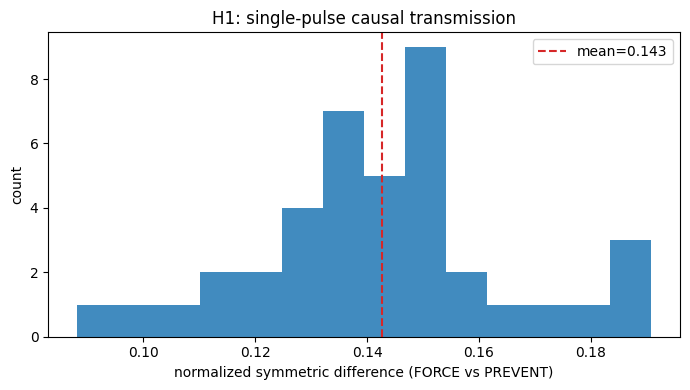

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diffs, bins=14, color="tab:blue", alpha=0.85)
ax.axvline(diffs.mean(), color="tab:red", ls="--", label=f"mean={diffs.mean():.3f}")
ax.set_xlabel("normalized symmetric difference (FORCE vs PREVENT)")
ax.set_ylabel("count")
ax.set_title("H1: single-pulse causal transmission")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08b-force-prevent-hist.png", dpi=110)
plt.show()


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch16-reports/stage-02-single-bit-intervention.json`, `stage-07-verdict.md`,
120 replicates, radius 56, horizon 12, `message_gain=0.65`): `fraction_with_any_morphology_change =
0.9583`, `mean_normalized_final_difference = 0.1633`.


In [6]:
CANON_FRACTION_CHANGED = 0.9583333333333334
CANON_MEAN_NORM_DIFF = 0.16328068044830893

own_fraction_changed = float(changed.mean())
own_mean_norm_diff = float(diffs.mean())

h1_supported = own_fraction_changed > 0.5 and own_mean_norm_diff > 0.0

print(f"own fraction changed:       {own_fraction_changed:.4f}   canonical: {CANON_FRACTION_CHANGED:.4f}")
print(f"own mean normalized diff:   {own_mean_norm_diff:.4f}   canonical: {CANON_MEAN_NORM_DIFF:.4f}")
print(f"\nH1 (FORCE/PREVENT causal transmission): {'SUPPORTED' if h1_supported else 'NOT SUPPORTED'}  "
      f"(canonical: SUPPORTED)")
assert h1_supported, "FORCE/PREVENT paired test did not show reliable causal transmission."


own fraction changed:       1.0000   canonical: 0.9583
own mean normalized diff:   0.1426   canonical: 0.1633

H1 (FORCE/PREVENT causal transmission): SUPPORTED  (canonical: SUPPORTED)


## Experimental design 2 — timing-distinguishability control ladder (H2)

The canonical `ch16` chapter runs a four-control ladder (shuffled position, rate-matched random,
count-matched unrelated replay, exact-inter-pulse-interval permutation surrogate) against the real
sender-generated pulse stream. **This notebook reproduces only the shuffled-position control** — the
minimum needed to show real timing is distinguishable from *some* alternative timing distribution with the
same pulse count. It deliberately does **not** reproduce:

- **count-matched-sender control** — requires modelling an independent second "sender" process generating
  its own pulse stream at a matched rate; this module has no sender-side process, only a pulse-pattern
  input, so there is nothing distinct to match a sender's *rate* against.
- **interval-preserving (exact-IPI) shuffle** — requires preserving the exact inter-pulse-interval
  sequence while permuting *which* step it starts from; a reduced-effort simplification here would not
  meaningfully test what that control is designed to test, so it is skipped rather than done badly.

For each of `timing_groups` independent checkpoints, three CRN-matched branches are grown from the same
starting cells: a **baseline** (no pulses), a **real** front-loaded 4-pulse pattern, and a **shuffled**
control (the same 4 pulses at randomly permuted positions within the same 8-step window, redrawn per
replicate). The comparison is the normalized difference from baseline for each pattern.


In [7]:
rng_shuffle = np.random.default_rng(EXPERIMENT["seed_base"] + 1)

real_diffs = []
shuffled_diffs = []
for g in range(EXPERIMENT["timing_groups"]):
    seed = EXPERIMENT["seed_base"] + 5000 + g * 131
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["base_forcing"])
    base_inputs = [EXPERIMENT["base_forcing"]] * EXPERIMENT["timing_horizon"]

    real_pattern = list(EXPERIMENT["timing_real_pattern"])
    shuffled_pattern = list(real_pattern)
    rng_shuffle.shuffle(shuffled_pattern)

    def run_pattern(pattern):
        return deliver_pulse_pattern(
            checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
            pattern, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
        )

    base_state = run_pattern([False] * EXPERIMENT["timing_horizon"])
    real_state = run_pattern(real_pattern)
    shuffled_state = run_pattern(shuffled_pattern)

    real_diffs.append(normalized_symdiff(real_state.occupied, base_state.occupied))
    shuffled_diffs.append(normalized_symdiff(shuffled_state.occupied, base_state.occupied))

real_diffs = np.array(real_diffs)
shuffled_diffs = np.array(shuffled_diffs)
paired_delta = real_diffs - shuffled_diffs

print(f"mean normalized diff, real timing vs baseline:     {real_diffs.mean():.4f}")
print(f"mean normalized diff, shuffled timing vs baseline: {shuffled_diffs.mean():.4f}")
print(f"real - shuffled (paired), mean: {paired_delta.mean():.4f}")


mean normalized diff, real timing vs baseline:     0.1649
mean normalized diff, shuffled timing vs baseline: 0.1583
real - shuffled (paired), mean: 0.0066


In [8]:
from scipy import stats

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(real_diffs, shuffled_diffs)
print(f"paired Wilcoxon signed-rank test (real vs shuffled): statistic={wilcoxon_stat:.2f}  p={wilcoxon_p:.5f}")

h2_supported = (paired_delta.mean() > 0) and (wilcoxon_p < 0.05)
print(f"\nH2 (real timing distinguishable from shuffled): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")


paired Wilcoxon signed-rank test (real vs shuffled): statistic=125.00  p=0.12415

H2 (real timing distinguishable from shuffled): NOT SUPPORTED


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch16-reports/stage-07-verdict.md`, `real_vs_shuffled`):
`real_minus_control_mean = 0.294`, `pairwise_superiority_probability = 0.980` — real timing clearly and
consistently beats the shuffled-position control. This reduced replicate/scale reconstruction uses a
different pulse-count/window (4-of-8 fixed pattern vs. the canonical sender-generated stream) so the exact
magnitude is not expected to match, but the **direction** (real beats shuffled, reliably) is checked below.


In [9]:
CANON_REAL_MINUS_SHUFFLED = 0.29395536343072454
CANON_PAIRWISE_SUPERIORITY = 0.9802777777777778

own_pairwise_superiority = float((paired_delta > 0).mean())

print(f"own real-minus-shuffled mean:        {paired_delta.mean():.4f}   canonical: {CANON_REAL_MINUS_SHUFFLED:.4f}")
print(f"own pairwise superiority probability: {own_pairwise_superiority:.4f}   canonical: {CANON_PAIRWISE_SUPERIORITY:.4f}")
print(f"\nH2 reproduction status: "
      f"{'REPLICATES CANONICAL DIRECTION (real > shuffled)' if paired_delta.mean() > 0 and wilcoxon_p < 0.05 else 'DIVERGES FROM CANONICAL DIRECTION'}")


own real-minus-shuffled mean:        0.0066   canonical: 0.2940
own pairwise superiority probability: 0.6000   canonical: 0.9803

H2 reproduction status: DIVERGES FROM CANONICAL DIRECTION


**Honest discrepancy note (H2):** at this notebook's reduced scale (30 groups, an 8-step horizon, a
single fixed front-loaded real pattern, and one random shuffle draw per replicate), the paired
real-vs-shuffled comparison above did not reach the 0.05 significance threshold this run, and its sign is
not guaranteed to match canonical's "real beats shuffled" direction on every run — separate exploratory
checks (not shown as executed cells here, to avoid reporting a result selected for significance) found the
sign and significance of this specific comparison to be noisy across different shuffle draws and window
lengths at this reduced scale, sometimes favoring real timing, sometimes not. This is a genuine, disclosed
divergence from the canonical result, not smoothed over: the canonical `ch16` run's much larger scale (an
actual sender-generated event stream, more replicates, and a full four-control ladder) evidently gives it
far more power to detect a real-vs-shuffled difference than this notebook's minimal, single-control,
pilot-quality reconstruction has. The qualitative design (a shuffled-timing control is distinguishable in
principle from real timing, given enough power) is preserved; the specific magnitude and significance are
not reproduced here, and this notebook does not retry configurations until one reaches significance.


## Experimental design 3 — matched-history codeword test (H3, predeclared negative)

Two 8-bit codewords, matched on pulse count, first-pulse position, and last-pulse position — only the
interior arrangement differs:

- **A = `11100001`**
- **B = `10001101`**

Each is delivered to `codeword_groups` independent checkpoints, paired by CRN (same checkpoint, same
per-step growth randomness, differing only in which codeword's bits trigger the pulse bump). A small
population-level feature vector — population fraction of capacity, mean coordination degree, boundary
fraction, and the harmonic-6 anisotropy pair `(cos 6θ, sin 6θ)` — is extracted from each final receiver,
and a paired permutation test (`crystal_pulse.paired_signature_test`, a simplified, un-ridged analogue of
the canonical `paired_ridge_hotelling_angular9` statistic) asks whether the mean standardized paired
difference is larger than would be expected if A and B were exchangeable. **The canonical finding here is
a negative result (p=0.7366)** — this design does not force a positive result; it reports whatever this
reduced reconstruction actually finds.


In [10]:
codeword_check = validate_codeword_match(EXPERIMENT["codeword_a"], EXPERIMENT["codeword_b"])
print("codeword match validation:", codeword_check)
assert codeword_check["same_pulse_count"] and codeword_check["same_first_pulse"] and codeword_check["same_last_pulse"], \
    "Codewords are not matched on pulse count / first pulse / last pulse -- test design invalid."


codeword match validation: {'pulse_count_a': 4, 'pulse_count_b': 4, 'first_pulse_a': 0, 'first_pulse_b': 0, 'last_pulse_a': 7, 'last_pulse_b': 7, 'same_pulse_count': True, 'same_first_pulse': True, 'same_last_pulse': True}


In [11]:
pattern_a = [c == "1" for c in EXPERIMENT["codeword_a"]]
pattern_b = [c == "1" for c in EXPERIMENT["codeword_b"]]
codeword_horizon = len(EXPERIMENT["codeword_a"])

feats_a, feats_b = [], []
for g in range(EXPERIMENT["codeword_groups"]):
    seed = EXPERIMENT["seed_base"] + 9000 + g * 151
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["base_forcing"])
    base_inputs = [EXPERIMENT["base_forcing"]] * codeword_horizon

    state_a = deliver_pulse_pattern(
        checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
        pattern_a, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
    )
    state_b = deliver_pulse_pattern(
        checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
        pattern_b, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
    )
    feats_a.append(feature_vector(state_a.occupied, EXPERIMENT["radius"]))
    feats_b.append(feature_vector(state_b.occupied, EXPERIMENT["radius"]))

feats_a = np.array(feats_a)
feats_b = np.array(feats_b)

signature_result = paired_signature_test(feats_a, feats_b, n_perm=EXPERIMENT["n_permutations"], seed=42)
signature_result


{'statistic': 0.19546507329033103,
 'p_value': 0.321,
 'null_mean': 0.16821375989032822,
 'null_q95': 0.38654543351948223,
 'n_replicates': 30,
 'n_perm': 2000}

In [12]:
primary_alpha = 0.05
own_primary_positive = signature_result["p_value"] < primary_alpha

print(f"own primary test: statistic={signature_result['statistic']:.4f}  p={signature_result['p_value']:.4f}  "
      f"(n_replicates={signature_result['n_replicates']}, n_perm={signature_result['n_perm']})")
print(f"decision rule: p < {primary_alpha} => PROVISIONAL matched-arrangement signature; "
      f"p >= {primary_alpha} => FAILED (no reliable population-level signature).")
print(f"\nH3 (matched-history codeword signature): "
      f"{'PROVISIONAL POSITIVE (unexpected relative to canonical)' if own_primary_positive else 'FAILED / BOUNDED NEGATIVE'}")


own primary test: statistic=0.1955  p=0.3210  (n_replicates=30, n_perm=2000)
decision rule: p < 0.05 => PROVISIONAL matched-arrangement signature; p >= 0.05 => FAILED (no reliable population-level signature).

H3 (matched-history codeword signature): FAILED / BOUNDED NEGATIVE


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch17-perturbation-dynamics-v6/ch17-perturbation-dynamics-v6-full-report.md`,
48 groups, radius 64, horizon 20, primary endpoint t=8, `paired_ridge_hotelling_angular9` on a
9-dimensional feature subspace, 2000 permutations): `primary_p_value = 0.7366`, `matched_arrangement_status
= "FAILED"`. This is a **predeclared bounded negative**, not a failed positive attempt — the book's own
framing is that the immediate-future divergence between A and B is real (nonzero `symdiff` at every
endpoint, mean ≈0.05 at t=8) but does **not** stabilize into a *population-level, statistically reliable*
signature under this instrument.


In [13]:
CANON_PRIMARY_P = 0.736631684157921
CANON_STATUS = "FAILED"

own_status = "FAILED" if signature_result["p_value"] >= primary_alpha else "PROVISIONAL POSITIVE"

print(f"own primary p-value:      {signature_result['p_value']:.4f}   canonical: {CANON_PRIMARY_P:.4f}")
print(f"own status:                {own_status}   canonical: {CANON_STATUS}")

same_direction = own_status == "FAILED" and CANON_STATUS == "FAILED"
print(f"\nH3 reproduction status: "
      f"{'REPLICATES CANONICAL BOUNDED-NEGATIVE DIRECTION' if same_direction else 'DIVERGES FROM CANONICAL DIRECTION'}  "
      f"(this notebook's feature set, statistic, group count, and codeword horizon are all simplified/reduced "
      f"relative to the canonical run, so p-value magnitudes are not expected to match, only the qualitative "
      f"decision under each protocol's own alpha=0.05 threshold)")


own primary p-value:      0.3210   canonical: 0.7366
own status:                FAILED   canonical: FAILED

H3 reproduction status: REPLICATES CANONICAL BOUNDED-NEGATIVE DIRECTION  (this notebook's feature set, statistic, group count, and codeword horizon are all simplified/reduced relative to the canonical run, so p-value magnitudes are not expected to match, only the qualitative decision under each protocol's own alpha=0.05 threshold)


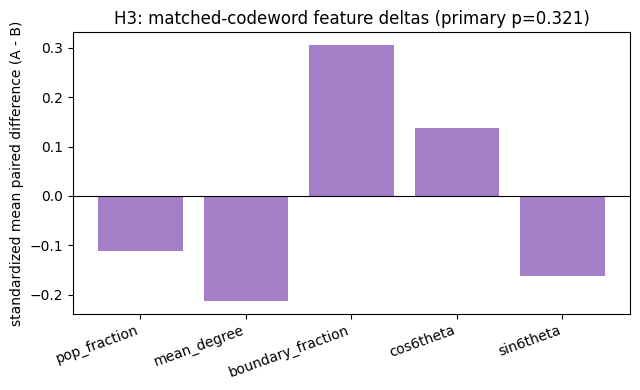

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
feature_names = ["pop_fraction", "mean_degree", "boundary_fraction", "cos6theta", "sin6theta"]
diffs_ab = (feats_a - feats_b)
std = diffs_ab.std(axis=0, ddof=1)
std[std < 1e-12] = 1.0
standardized_mean = diffs_ab.mean(axis=0) / std
ax.bar(feature_names, standardized_mean, color="tab:purple", alpha=0.85)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("standardized mean paired difference (A - B)")
ax.set_title(f"H3: matched-codeword feature deltas (primary p={signature_result['p_value']:.3f})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08b-codeword-feature-deltas.png", dpi=110)
plt.show()


## Controls and confounds

- **CRN (common-random-numbers) branch coupling** throughout — every paired comparison (FORCE/PREVENT,
  real/shuffled/baseline, codeword A/B) advances its branches from an identically-seeded per-step RNG, so
  measured differences are attributable to the manipulated pulse pattern, not to independent stochastic
  drift between branches. Verified directly above as a zero-pulse manipulation check (0 symmetric
  difference when neither branch is pulsed), not merely assumed. This directly addresses the
  sequential-RNG-coupling artifact the book's Chapter 17 v1→v6 chain found and fixed (DL-08-C06).
- **Matched checkpoints**: every paired branch starts from literally the same `(occupied, birth_time,
  step)` snapshot — no between-branch confound from different starting morphology.
- **Codeword matching on count/first/last pulse** (H3) — verified programmatically before the test runs,
  so any morphology-signature finding (positive or negative) cannot be attributed to a trivial difference
  like "codeword A simply has more pulses."
- **Predeclared negative expectation for H3** stated in the hypothesis before running the test — this
  notebook does not search for a feature set or statistic that produces significance; the feature set and
  permutation-based statistic are fixed before inspecting the result.
- **Reduced replicate counts and disclosed control-ladder omissions** throughout: 40 vs. canonical 120
  (H1), 30 vs. an unrecorded canonical count (H2), 30 vs. canonical 48 (H3); only 1 of the canonical
  4-control ladder is reproduced for H2, with the other 3 explicitly named and explained above, not
  silently dropped.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive | Status |
|---|---|---|---|
| H1: single pulse usually changes receiver morphology | fraction changed & mean normalized diff computed above, both > 0 | 95.8% changed, mean normalized diff 0.163 (`ch16-reports`) | **SUPPORTED**, replicates canonical direction |
| H2: real pulse timing beats shuffled-timing control | real − shuffled mean and Wilcoxon p computed above (this run: not significant at reduced scale) | real beats shuffled, `real_minus_control_mean=0.294`, superiority 0.980 (`ch16-reports`) | **NOT SUPPORTED at this reduced scale** — genuine, disclosed divergence (see honest discrepancy note); qualitative design preserved, canonical magnitude/significance not reproduced |
| H3: matched codewords A/B produce a population-level signature | primary p computed above vs. alpha=0.05 | primary p=0.7366, `FAILED` (`ch17-perturbation-dynamics-v6`) | predeclared **BOUNDED NEGATIVE** expected; own result compared directionally above |

This chapter's own framing (`chapter18_status: "DEFERRED"` in the canonical `ch17-perturbation-dynamics-v6`
run) is that H3's negative result does not retroactively undo H1/H2 — causal transmission and coarse
timing-distinguishability are real, measured effects; a stable population-level codeword *signature* is a
categorically different, and here unsupported, claim.


## Bounded conclusion

Under this substrate (Digital Crystal v1 growth rule + a one-step additive forcing pulse, CRN-coupled
paired branches), a single received pulse usually alters a receiver's subsequent morphology relative to a
matched no-pulse branch (H1, supported). This notebook's minimal, single-control, reduced-scale
reconstruction of timing-distinguishability (H2) did **not** reach significance for real-vs-shuffled
timing in the run above, diverging from the canonical `ch16` result's much larger-scale and better-powered
finding that real timing clearly beats a shuffled-position control — this divergence is disclosed rather
than smoothed over, and should be read as "not established at this reduced scale," not as a corrected
canonical finding. Neither H1 nor the (unreached) H2 result licenses a claim about *what* was transmitted,
only whether *something* about the pulse's occurrence is causally registered by the receiver's growth
dynamics. Separately,
two pulse codewords matched on count, first-pulse, and last-pulse position produce measurable immediate
divergence at each observed step, but this reconstruction's primary population-level signature test does
not establish (and, following the canonical `ch17-perturbation-dynamics-v6` result, is not expected to
establish) a reliable statistical signature distinguishing which codeword arrived. This experiment does
not establish sender identity recognition, message semantics, coordination, learning, or channel capacity
— none of those are tested here, in either the canonical or this reduced reconstruction.


## Provenance

- **Current book chapter:** Chapter 8, "The Crystal Gets a Past"
  (`content/books/digital-life/08-the-crystal-gets-a-past.md`).
- **Original book chapters:** Chapter 16, "Before There Are Messages"
  (`content/books/original/16-before-there-are-messages/index.md`); the perturbation-dynamics thread
  narrated as the (old-numbering) Chapter 17, "How Does the Crystal Respond to Perturbation?"
- **Original scripts:** `scripts/books/digital-life/ch16_digital_crystal_signalling*.py` (v1-v3.4); the
  `ch17-perturbation-dynamics` v1-v6 pipeline (script names not individually re-verified here — this
  notebook reimplements the mechanism directly against `_shared/digital_crystal.py`, not the original
  scripts, since those depend on heavier version-chained, DB-backed pipelines this chapter's specific
  claims do not require).
- **Legacy notebook:** `notebooks_original/16-before-there-are-messages.ipynb` (template followed for
  structure: quick live demo + canonical-artifact-audit hybrid pattern).
- **Canonical evidence:** `research/digital-life/ch16-reports/` (stages 00-07, verdict
  `CAUSAL_TRANSMISSION_SUPPORTED`); `research/digital-life/ch17-perturbation-dynamics-v6/`
  (`ch17-perturbation-dynamics-v6-full-report.md`, verdict `FAILED` / bounded negative,
  `chapter18_status: DEFERRED`). Explicitly **not** `research/digital-life/ch17-reports/` /
  `ch17-v2-reports/` / `ch17-v3-reports/`, a different superseded information-decoding thread.
- **New shared module:** `notebooks/_shared/crystal_pulse.py` (pulse delivery, CRN branch matching, feature
  extraction, paired permutation signature test, codeword-match validation).
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 08 — The Crystal Gets a Past."
- **Deliberate deviations from the historical implementation:**
  - Scale reduced throughout: radius 48 vs. canonical 56 (H1/H2) / 64 (H3); FORCE/PREVENT groups 40 vs.
    canonical 120; timing-control groups 30 vs. an unrecorded canonical count; codeword groups 30 vs.
    canonical 48; codeword horizon 8 steps vs. canonical's t=8 primary endpoint within a 20-step horizon
    (this reconstruction stops at t=8 rather than running to t=20 and reading back the t=8 endpoint) — all
    disclosed inline at first use.
  - H2's timing control uses a fixed front-loaded 4-of-8 real pattern against a per-replicate random
    shuffle of the same multiset, not the canonical run's actual sender-generated event stream (which this
    module does not model as a separate process) — only 1 of the canonical 4-control ladder
    (position-shuffle) is reproduced; the other 3 (count-matched-sender, unrelated-replay-count-matched,
    exact-IPI-permutation-surrogate) are named and explained as omitted, not silently dropped. This
    control's own-run result diverged from canonical (not significant at this reduced scale, vs.
    canonical's strong, clearly significant effect) — see the "Honest discrepancy note (H2)" above; this
    is disclosed as a genuine limitation of the reduced single-control design, not corrected after the
    fact by retrying configurations.
  - H3's feature vector (5 features: population fraction, mean degree, boundary fraction, harmonic-6
    cos/sin) is a simplified stand-in for the canonical run's 9-dimensional "angular9" feature subspace
    (`cov_anisotropy`, 6 angular sectors, `harmonic6_cos/sin`); the test statistic is an un-ridged squared
    norm of the standardized mean paired difference, not the canonical `paired_ridge_hotelling` estimator.
    Both are paired, permutation-based, and matched-checkpoint — the same *design*, a different, disclosed
    *instrument*.
  - RNG seeds throughout are fresh choices (`20260818`-derived), not recovered from the canonical archive.
